In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import seaborn as sns

sns.set_theme(style='whitegrid', context='paper', font_scale=1.2)
matplotlib.rcParams.update({
    'figure.figsize': (4.5, 3.5),
    'figure.dpi': 120,
})


In [2]:
# ── 데이터 로드 ──────────────────────────────────────────────────────────
_HERE = os.path.dirname(os.path.abspath('__file__'))  # notebook 위치
CSV_PATH = os.path.join(_HERE, 'combined_results.csv')

df_all = pd.read_csv(CSV_PATH)
df = df_all[df_all['ratio'] < 1.0]  # ratio=1.0 제외

# Oracle: unseen data ratio=1.0, seen_ratio=1.0
oracle_val = df_all[(df_all['ratio'] == 1.0) & (df_all['seen_ratio'] == 1.0)]['unseen_reg'].mean()
print(f'shape: {df.shape}')
df.head()


shape: (232, 43)


,ratio,seen_ratio,game,unseen_games,seen_acc,unseen_acc,seen_reg,unseen_reg,seen_avg_diff,unseen_avg_diff,...,zelda_enum_1,zelda_enum_2,zelda_enum_3,zelda_enum_4,run_id,run_name,run_state,cfg_unseen_games,cfg_seen_ratio,cfg_seed
0,0.00,0.5,all,dmzd,1.0,1.0000,0.007379,0.003659,0.067190,0.051386,...,0.129072,0.089270,0.040951,0.022730,hg9fxa98,clipdec-unseen-game-all_unseen-dmzd_sr-0.5_md-...,finished,dmzd,0.5,0
1,0.01,0.5,all,dmzd,1.0,1.0000,0.007851,0.004678,0.069613,0.060068,...,0.114656,0.091199,0.045757,0.058518,hg9fxa98,clipdec-unseen-game-all_unseen-dmzd_sr-0.5_md-...,finished,dmzd,0.5,0
2,0.03,0.5,all,dmzd,1.0,1.0000,0.007871,0.002514,0.070269,0.041880,...,0.099150,0.057280,0.027261,0.044447,hg9fxa98,clipdec-unseen-game-all_unseen-dmzd_sr-0.5_md-...,finished,dmzd,0.5,0
3,0.05,0.5,all,dmzd,1.0,0.9995,0.007279,0.002418,0.067407,0.038629,...,0.075455,0.078001,0.033783,0.019540,hg9fxa98,clipdec-unseen-game-all_unseen-dmzd_sr-0.5_md-...,finished,dmzd,0.5,0
4,0.10,0.5,all,dmzd,1.0,0.9995,0.007330,0.002600,0.069395,0.039848,...,0.088239,0.063067,0.024184,0.023302,hg9fxa98,clipdec-unseen-game-all_unseen-dmzd_sr-0.5_md-...,finished,dmzd,0.5,0


In [3]:
# ── unseen_games 별로 평균 집계 ───────────────────────────────────────────
# 같은 (ratio, seen_ratio) 조합의 여러 unseen_games 를 평균
agg_df = (
    df.groupby(['ratio', 'seen_ratio'])
    .agg(unseen_reg_mean=('unseen_reg', 'mean'),
         unseen_reg_std=('unseen_reg', 'std'),
         count=('unseen_reg', 'count'))
    .reset_index()
)
agg_df['unseen_reg_se'] = agg_df['unseen_reg_std'] / np.sqrt(agg_df['count'])
agg_df


,ratio,seen_ratio,unseen_reg_mean,unseen_reg_std,count,unseen_reg_se
0,0.00,0.0,0.086482,0.010364,10,0.003278
1,0.00,0.1,0.012505,NaN,1,NaN
2,0.00,0.5,0.006928,0.002530,10,0.000800
3,0.00,1.0,0.007965,0.003056,8,0.001080
4,0.01,0.0,0.008790,0.006738,10,0.002131
5,0.01,0.1,0.010214,NaN,1,NaN
6,0.01,0.5,0.006403,0.002106,10,0.000666
7,0.01,1.0,0.006787,0.002333,8,0.000825
8,0.03,0.0,0.006190,0.004575,10,0.001447
9,0.03,0.1,0.010410,NaN,1,NaN


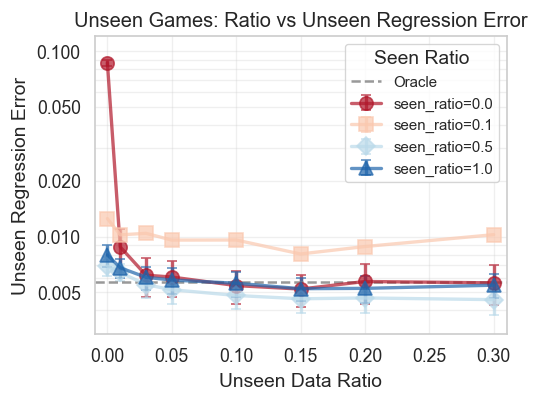

In [4]:
# ── 플롯: ratio vs unseen_reg (seen_ratio 별 색/마커) ────────────────────
palette = sns.color_palette('deep', 4)
seen_ratios = sorted(agg_df['seen_ratio'].unique())
cmap = plt.cm.RdBu
palette = [cmap(x) for x in np.linspace(0.1, 0.9, len(seen_ratios))]  # 양 끝 진하게
COLORS = dict(zip(seen_ratios, palette))
MARKERS = {0.0: 'o', 0.1: 's', 0.5: 'D', 1.0: '^'}

fig, ax = plt.subplots()

for sr in sorted(agg_df['seen_ratio'].unique()):
    sub = agg_df[agg_df['seen_ratio'] == sr].sort_values('ratio')
    ax.errorbar(
        sub['ratio'], sub['unseen_reg_mean'],
        yerr=sub['unseen_reg_se'],
        label=f'seen_ratio={sr}',
        color=COLORS.get(sr, 'gray'),
        marker=MARKERS.get(sr, 'x'),
        markersize=8,
        linewidth=2,
        capsize=3,
        alpha=0.7,
    )

ax.axhline(y=oracle_val, color='gray', linestyle='--', linewidth=1.5, alpha=0.8, label='Oracle')

ax.set_yscale('log')
ax.set_xlabel('Unseen Data Ratio')
ax.set_ylabel('Unseen Regression Error')
ax.set_title('Unseen Games: Ratio vs Unseen Regression Error')
# set title font size
ax.title.set_fontsize(12)
ax.legend(title='Seen Ratio', fontsize=9)
ax.set_xlim(-0.01, 0.31)
ax.set_ylim(0.003, 0.12)
ax.yaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
ax.set_yticks([0.005, 0.01, 0.02, 0.05, 0.1])
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.3f'))
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(os.path.join(_HERE, 'ratio_vs_unseen_reg.png'), bbox_inches='tight', facecolor='white')
plt.show()
